# Real-Time Driver Safety Monitoring Using Facial Emotion Recognition
**MSc Applied Artificial Intelligence — Sheffield Hallam University**

This notebook trains two models:
- **Model 1:** Emotion classifier on FER-2013 (7 classes)
- **Model 2:** Drowsiness detector on MRL Eye Dataset (Open/Closed)

Both use MobileNetV2 with transfer learning. Outputs: `.h5` model files + evaluation graphs.

## Cell 1 — Install Dependencies

In [4]:
# Dependencies
!pip install -q opencv-python-headless matplotlib seaborn scikit-learn


## Cell 2 — Import Libraries

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 — Load FER-2013 Dataset

Dataset path: `/kaggle/input/datasets/msambare/fer2013/`

In [6]:
# Confirmed dataset paths
fer_path = '/kaggle/input/datasets/msambare/fer2013'
mrl_path = '/kaggle/input/datasets/tauilabdelilah/mrl-eye-dataset'

print('FER-2013:', fer_path)
print('MRL Eye: ', mrl_path)

for split in ['train', 'test']:
    classes = sorted(os.listdir(os.path.join(fer_path, split)))
    print(f'  FER {split.upper()} — {len(classes)} classes: {classes}')


FER-2013: /kaggle/input/datasets/msambare/fer2013
MRL Eye:  /kaggle/input/datasets/tauilabdelilah/mrl-eye-dataset
  FER TRAIN — 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  FER TEST — 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Cell 4 — FER-2013 Data Generators

In [7]:
# Configuration
IMG_SIZE = 96
BATCH_SIZE = 64

# Augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Test set — rescale only
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(fer_path, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(fer_path, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_gen.class_indices)
print("Training batches:", len(train_gen))
print("Test batches:", len(test_gen))

# Save class indices to disk so downstream cells (and demo.py) never have to
# guess/assume label order — this avoids a silent label-mismatch bug.
import json as _json
with open('/kaggle/working/emotion_class_indices.json', 'w') as f:
    _json.dump(train_gen.class_indices, f, indent=2)
print("Saved emotion_class_indices.json")


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Training batches: 449
Test batches: 113
Saved emotion_class_indices.json


## Cell 5 — Handle Class Imbalance (FER-2013)

In [8]:
# FER-2013 is class-imbalanced — compute weights to compensate

labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
class_names = list(train_gen.class_indices.keys())
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weight_dict[i]:.3f}")

Class weights:
  angry: 1.027
  disgust: 9.407
  fear: 1.001
  happy: 0.568
  neutral: 0.826
  sad: 0.849
  surprise: 1.293


## Cell 6 — Build Model 1 (Emotion Classifier)

In [9]:
def build_model(num_classes, input_shape=(96, 96, 3)):
    # MobileNetV2 base — ImageNet weights, top excluded
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze base for initial training
    base.trainable = False
    
    # Classification head
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base.input, outputs=output)
    return model

# Emotion model — 7 classes
emotion_model = build_model(num_classes=7)

emotion_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model 1 initialised.")
print(f"Total parameters: {emotion_model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in emotion_model.trainable_weights]):,}")

I0000 00:00:1784096795.778899      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model 1 initialised.
Total parameters: 2,619,719
Trainable parameters: 361,735


## Cell 7 — Train Model 1 (Phase 1: Top Layers Only)

In [10]:
# Training callbacks
callbacks_emotion = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/emotion_model_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("Phase 1 — base frozen")
print("-" * 40)

history_emotion_p1 = emotion_model.fit(
    train_gen,
    epochs=20,
    validation_data=test_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_emotion,
    verbose=1
)

# Persist history to disk immediately — history objects only live in kernel
# memory, so if the kernel restarts before Cell 9 runs, this is the only way
# to recover the training curves without retraining from scratch.
import pickle
with open('/kaggle/working/history_emotion_p1.pkl', 'wb') as f:
    pickle.dump(history_emotion_p1.history, f)
print("Saved history_emotion_p1.pkl")


Phase 1 — base frozen
----------------------------------------
Epoch 1/20


I0000 00:00:1784096813.756918     152 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.2248 - loss: 1.9561
Epoch 1: val_accuracy improved from None to 0.32795, saving model to /kaggle/working/emotion_model_best.h5



Epoch 1: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 308s 656ms/step - accuracy: 0.2533 - loss: 1.8545 - val_accuracy: 0.3279 - val_loss: 1.7350 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.2947 - loss: 1.7465
Epoch 2: val_accuracy improved from 0.32795 to 0.40680, saving model to /kaggle/working/emotion_model_best.h5



Epoch 2: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 220ms/step - accuracy: 0.2988 - loss: 1.7391 - val_accuracy: 0.4068 - val_loss: 1.5971 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.3262 - loss: 1.7139
Epoch 3: val_accuracy improved from 0.40680 to 0.40875, saving model to /kaggle/working/emotion_model_best.h5


...


Epoch 9: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 223ms/step - accuracy: 0.3843 - loss: 1.5429 - val_accuracy: 0.4192 - val_loss: 1.5274 - learning_rate: 5.0000e-04
Epoch 10/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.3854 - loss: 1.5313
Epoch 10: val_accuracy did not improve from 0.41920
449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 221ms/step - accuracy: 0.3848 - loss: 1.5389 - val_accuracy: 0.4135 - val_loss: 1.5284 - learning_rate: 5.0000e-04
Epoch 11/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.3855 - loss: 1.5579
Epoch 11: val_accuracy improved from 0.41920 to 0.42338, saving model to /kaggle/working/emotion_model_best.h5



Epoch 11: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 224ms/step - accuracy: 0.3882 - loss: 1.5398 - val_accuracy: 0.4234 - val_loss: 1.5325 - learning_rate: 5.0000e-04
Epoch 12/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.3904 - loss: 1.5090
Epoch 12: val_accuracy did not improve from 0.42338

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 223ms/step - accuracy: 0.3900 - loss: 1.5115 - val_accuracy: 0.4107 - val_loss: 1.5391 - learning_rate: 5.0000e-04
Epoch 13/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.3944 - loss: 1.5184
Epoch 13: val_accuracy improved from 0.42338 to 0.42352, saving model to /kaggle/working/emotion_model_best.h5



Epoch 13: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 223ms/step - accuracy: 0.3964 - loss: 1.5082 - val_accuracy: 0.4235 - val_loss: 1.5265 - learning_rate: 2.5000e-04
Epoch 14/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4019 - loss: 1.4997
Epoch 14: val_accuracy did not improve from 0.42352
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 223ms/step - accuracy: 0.4027 - loss: 1.4997 - val_accuracy: 0.4170 - val_loss: 1.5317 - learning_rate: 2.5000e-04
Epoch 15/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.4023 - loss: 1.5010
Epoch 15: val_accuracy did not improve from 0.42352
449/449 ━━━━━━━━━━━━━━━━━━━━ 109s 242ms/step - accuracy: 0.4018 - loss: 1.4958 - val_accuracy: 0.4198 - val_loss: 1.5267 - learning_rate: 2.5000e-04
Epoch 16/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.3980 - loss: 1.4966
Epoch 16: val_accuracy did not improve from 0.42352

Epoch 16: ReduceLROnPlateau reducing learning rate to 0


Epoch 18: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 317ms/step - accuracy: 0.4091 - loss: 1.4713 - val_accuracy: 0.4238 - val_loss: 1.5075 - learning_rate: 1.2500e-04
Epoch 19/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.4091 - loss: 1.4768
Epoch 19: val_accuracy improved from 0.42379 to 0.42435, saving model to /kaggle/working/emotion_model_best.h5



Epoch 19: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 133s 296ms/step - accuracy: 0.4116 - loss: 1.4735 - val_accuracy: 0.4244 - val_loss: 1.5071 - learning_rate: 1.2500e-04
Epoch 20/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.4079 - loss: 1.4673
Epoch 20: val_accuracy did not improve from 0.42435
449/449 ━━━━━━━━━━━━━━━━━━━━ 130s 290ms/step - accuracy: 0.4091 - loss: 1.4721 - val_accuracy: 0.4186 - val_loss: 1.5285 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 19.
Saved history_emotion_p1.pkl


## Cell 8 — Fine-Tune Model 1 (Phase 2: Unfreeze Top Base Layers)

In [11]:
# Unfreeze last 30 layers for fine-tuning
for layer in emotion_model.layers[:-30]:
    layer.trainable = False
for layer in emotion_model.layers[-30:]:
    layer.trainable = True

# Lower learning rate for fine-tuning
emotion_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 — fine-tuning last 30 layers")
print("-" * 40)

history_emotion_p2 = emotion_model.fit(
    train_gen,
    epochs=15,
    validation_data=test_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_emotion,
    verbose=1
)

print("Model 1 training complete.")

# Persist history to disk
import pickle
with open('/kaggle/working/history_emotion_p2.pkl', 'wb') as f:
    pickle.dump(history_emotion_p2.history, f)
print("Saved history_emotion_p2.pkl")


Phase 2 — fine-tuning last 30 layers
----------------------------------------
Epoch 1/15


2026-07-15 07:06:44.781448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 07:06:44.966449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 07:06:45.220744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 07:06:45.435971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


142/449 ━━━━━━━━━━━━━━━━━━━━ 1:24 274ms/step - accuracy: 0.2796 - loss: 2.3538

2026-07-15 07:07:35.169547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 07:07:35.355701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 07:07:35.622860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 07:07:35.829419: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.3138 - loss: 2.0413
Epoch 1: val_accuracy did not improve from 0.42435
449/449 ━━━━━━━━━━━━━━━━━━━━ 173s 336ms/step - accuracy: 0.3409 - loss: 1.7985 - val_accuracy: 0.4069 - val_loss: 1.5321 - learning_rate: 1.0000e-04
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.3896 - loss: 1.5441
Epoch 2: val_accuracy improved from 0.42435 to 0.44260, saving model to /kaggle/working/emotion_model_best.h5


...


Epoch 6: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 97s 217ms/step - accuracy: 0.4795 - loss: 1.2946 - val_accuracy: 0.4890 - val_loss: 1.3213 - learning_rate: 1.0000e-04
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.4846 - loss: 1.2755
Epoch 7: val_accuracy did not improve from 0.48899
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.4889 - loss: 1.2798 - val_accuracy: 0.4876 - val_loss: 1.3367 - learning_rate: 1.0000e-04
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5062 - loss: 1.2400
Epoch 8: val_accuracy improved from 0.48899 to 0.49889, saving model to /kaggle/working/emotion_model_best.h5



Epoch 8: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 232ms/step - accuracy: 0.5064 - loss: 1.2338 - val_accuracy: 0.4989 - val_loss: 1.3079 - learning_rate: 1.0000e-04
Epoch 9/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5118 - loss: 1.2090
Epoch 9: val_accuracy improved from 0.49889 to 0.51282, saving model to /kaggle/working/emotion_model_best.h5



Epoch 9: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 224ms/step - accuracy: 0.5086 - loss: 1.2175 - val_accuracy: 0.5128 - val_loss: 1.2977 - learning_rate: 1.0000e-04
Epoch 10/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5232 - loss: 1.1748
Epoch 10: val_accuracy improved from 0.51282 to 0.51853, saving model to /kaggle/working/emotion_model_best.h5



Epoch 10: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 231ms/step - accuracy: 0.5214 - loss: 1.1912 - val_accuracy: 0.5185 - val_loss: 1.2648 - learning_rate: 1.0000e-04
Epoch 11/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5331 - loss: 1.1556
Epoch 11: val_accuracy did not improve from 0.51853
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 231ms/step - accuracy: 0.5312 - loss: 1.1604 - val_accuracy: 0.4975 - val_loss: 1.3119 - learning_rate: 1.0000e-04
Epoch 12/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.5336 - loss: 1.1465
Epoch 12: val_accuracy did not improve from 0.51853
449/449 ━━━━━━━━━━━━━━━━━━━━ 106s 236ms/step - accuracy: 0.5364 - loss: 1.1470 - val_accuracy: 0.5162 - val_loss: 1.2927 - learning_rate: 1.0000e-04
Epoch 13/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5443 - loss: 1.1178
Epoch 13: val_accuracy improved from 0.51853 to 0.53079, saving model to /kaggle/working/emotion_model_best.


Epoch 13: finished saving model to /kaggle/working/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 103s 230ms/step - accuracy: 0.5433 - loss: 1.1219 - val_accuracy: 0.5308 - val_loss: 1.2564 - learning_rate: 1.0000e-04
Epoch 14/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5521 - loss: 1.0785
Epoch 14: val_accuracy did not improve from 0.53079
449/449 ━━━━━━━━━━━━━━━━━━━━ 105s 235ms/step - accuracy: 0.5511 - loss: 1.0955 - val_accuracy: 0.5033 - val_loss: 1.3191 - learning_rate: 1.0000e-04
Epoch 15/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5579 - loss: 1.0747
Epoch 15: val_accuracy did not improve from 0.53079
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 241ms/step - accuracy: 0.5582 - loss: 1.0777 - val_accuracy: 0.5049 - val_loss: 1.3297 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 13.
Model 1 training complete.
Saved history_emotion_p2.pkl


## Cell 9 — Evaluate Model 1 + Plot Results

In [12]:
# Load best checkpoint
from tensorflow.keras.models import load_model
emotion_model = load_model('/kaggle/working/emotion_model_best.h5')

# Test set evaluation
test_gen.reset()
loss, accuracy = emotion_model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# Predictions
test_gen.reset()
y_pred_probs = emotion_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

emotion_labels = list(test_gen.class_indices.keys())

# Per-class metrics
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))

Test Accuracy: 53.08%
Test Loss: 1.2564
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.51      0.28      0.36       958
     disgust       0.45      0.62      0.52       111
        fear       0.63      0.07      0.13      1024
       happy       0.68      0.79      0.73      1774
     neutral       0.43      0.63      0.51      1233
         sad       0.40      0.55      0.46      1247
    surprise       0.68      0.64      0.66       831

    accuracy                           0.53      7178
   macro avg       0.54      0.51      0.48      7178
weighted avg       0.55      0.53      0.50      7178



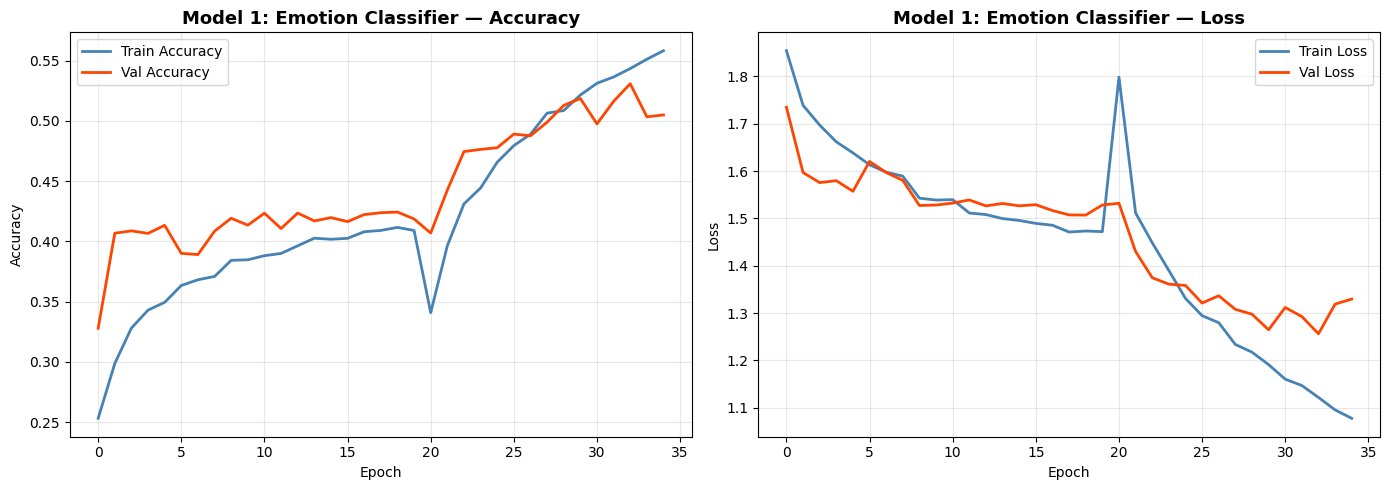

emotion_training_curves.png saved.


In [13]:
# Merge phase 1 and phase 2 histories.
# If the kernel was restarted between training and this cell, the history
# variables won't exist in memory — fall back to the pickled versions saved
# in Cells 7 and 8 instead of crashing with a NameError.
import pickle

def combine_histories(h1, h2):
    combined = {}
    for key in h1:
        combined[key] = h1[key] + h2[key]
    return combined

try:
    h1_dict = history_emotion_p1.history
    h2_dict = history_emotion_p2.history
except NameError:
    print("history_emotion_p1/p2 not in memory — loading from pickled files instead.")
    with open('/kaggle/working/history_emotion_p1.pkl', 'rb') as f:
        h1_dict = pickle.load(f)
    with open('/kaggle/working/history_emotion_p2.pkl', 'rb') as f:
        h2_dict = pickle.load(f)

emotion_history = combine_histories(h1_dict, h2_dict)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(emotion_history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(emotion_history['val_accuracy'], label='Val Accuracy', color='orangered', linewidth=2)
axes[0].set_title('Model 1: Emotion Classifier — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(emotion_history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(emotion_history['val_loss'], label='Val Loss', color='orangered', linewidth=2)
axes[1].set_title('Model 1: Emotion Classifier — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/emotion_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("emotion_training_curves.png saved.")


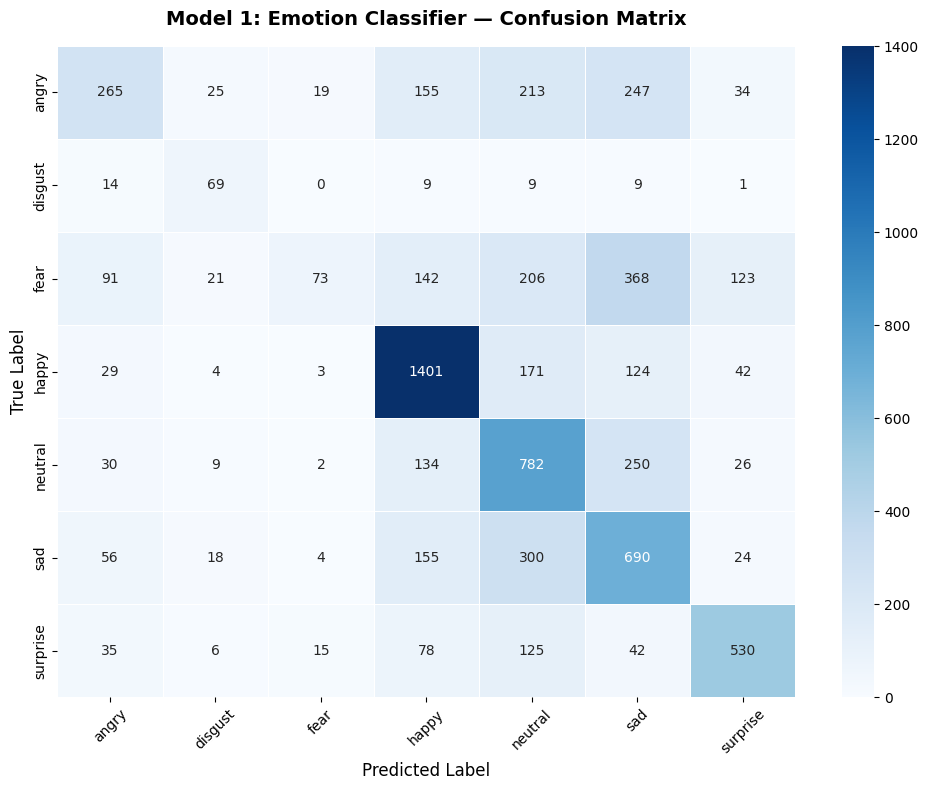

emotion_confusion_matrix.png saved.


In [14]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_labels,
    yticklabels=emotion_labels,
    linewidths=0.5
)
plt.title('Model 1: Emotion Classifier — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/kaggle/working/emotion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("emotion_confusion_matrix.png saved.")

---
# Model 2: Drowsiness Detector (MRL Eye Dataset)

Dataset path: `/kaggle/input/datasets/tauilabdelilah/mrl-eye-dataset/`

## Cell 10 — Load MRL Eye Dataset

In [15]:
# Dataset structure verification
mrl_path = '/kaggle/input/datasets/tauilabdelilah/mrl-eye-dataset'

print("Dataset structure:")
for root, dirs, files in os.walk(mrl_path):
    level = root.replace(mrl_path, '').count(os.sep)
    indent = ' ' * 2 * level
    folder = os.path.basename(root)
    if level <= 2:
        count = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if count > 0:
            print(f"{indent}{folder}/  ({count} images)")
        elif level <= 1:
            print(f"{indent}{folder}/")

Dataset structure:
mrl-eye-dataset/
  data/


## Cell 11 — MRL Data Generators

In [16]:
# Balanced dataset — no class weighting required
IMG_SIZE_EYE = 96
BATCH_SIZE_EYE = 64

eye_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.15  # 15% of training data used for validation
)

eye_test_datagen = ImageDataGenerator(rescale=1./255)

# Training subset
eye_train_gen = eye_train_datagen.flow_from_directory(
    os.path.join(mrl_path, 'data/train'),
    target_size=(IMG_SIZE_EYE, IMG_SIZE_EYE),
    batch_size=BATCH_SIZE_EYE,
    color_mode='rgb',
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation subset
eye_val_gen = eye_train_datagen.flow_from_directory(
    os.path.join(mrl_path, 'data/train'),
    target_size=(IMG_SIZE_EYE, IMG_SIZE_EYE),
    batch_size=BATCH_SIZE_EYE,
    color_mode='rgb',
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Test set
eye_test_gen = eye_test_datagen.flow_from_directory(
    os.path.join(mrl_path, 'data/test'),
    target_size=(IMG_SIZE_EYE, IMG_SIZE_EYE),
    batch_size=BATCH_SIZE_EYE,
    color_mode='rgb',
    class_mode='binary',
    shuffle=False
)

print("Eye class indices:", eye_train_gen.class_indices)
print(f"Training samples: {eye_train_gen.samples}")
print(f"Validation samples: {eye_val_gen.samples}")
print(f"Test samples: {eye_test_gen.samples}")

# Save class indices to disk (see note in Cell 4)
import json as _json
with open('/kaggle/working/eye_class_indices.json', 'w') as f:
    _json.dump(eye_train_gen.class_indices, f, indent=2)
print("Saved eye_class_indices.json")


Found 69424 images belonging to 2 classes.
Found 12251 images belonging to 2 classes.
Found 3223 images belonging to 2 classes.
Eye class indices: {'close eyes': 0, 'open eyes': 1}
Training samples: 69424
Validation samples: 12251
Test samples: 3223
Saved eye_class_indices.json


## Cell 12 — Build Model 2 (Drowsiness Detector)

In [17]:
# Drowsiness model — binary classification
base_eye = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_EYE, IMG_SIZE_EYE, 3))
base_eye.trainable = False

x = base_eye.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
output_eye = Dense(1, activation='sigmoid')(x)  # Binary output

drowsiness_model = Model(inputs=base_eye.input, outputs=output_eye)

drowsiness_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model 2 initialised.")
print(f"Total parameters: {drowsiness_model.count_params():,}")

Model 2 initialised.
Total parameters: 2,430,273


## Cell 13 — Train Model 2

In [18]:
callbacks_eye = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/drowsiness_model_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("Phase 1 — base frozen")
print("-" * 40)

history_eye_p1 = drowsiness_model.fit(
    eye_train_gen,
    epochs=15,
    validation_data=eye_val_gen,
    callbacks=callbacks_eye,
    verbose=1
)

# Persist Phase 1 history immediately
import pickle
with open('/kaggle/working/history_eye_p1.pkl', 'wb') as f:
    pickle.dump(history_eye_p1.history, f)
print("Saved history_eye_p1.pkl")

# Unfreeze last 20 layers for fine-tuning
for layer in drowsiness_model.layers[:-20]:
    layer.trainable = False
for layer in drowsiness_model.layers[-20:]:
    layer.trainable = True

drowsiness_model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 — fine-tuning last 20 layers")
print("-" * 40)

history_eye_p2 = drowsiness_model.fit(
    eye_train_gen,
    epochs=10,
    validation_data=eye_val_gen,
    callbacks=callbacks_eye,
    verbose=1
)

print("Model 2 training complete.")

# Persist Phase 2 history immediately
with open('/kaggle/working/history_eye_p2.pkl', 'wb') as f:
    pickle.dump(history_eye_p2.history, f)
print("Saved history_eye_p2.pkl")


Phase 1 — base frozen
----------------------------------------
Epoch 1/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.8992 - loss: 0.2391
Epoch 1: val_accuracy improved from None to 0.90572, saving model to /kaggle/working/drowsiness_model_best.h5



Epoch 1: finished saving model to /kaggle/working/drowsiness_model_best.h5
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 731s 664ms/step - accuracy: 0.9281 - loss: 0.1826 - val_accuracy: 0.9057 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 2/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9472 - loss: 0.1350
Epoch 2: val_accuracy improved from 0.90572 to 0.91462, saving model to /kaggle/working/drowsiness_model_best.h5



Epoch 2: finished saving model to /kaggle/working/drowsiness_model_best.h5
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 327s 302ms/step - accuracy: 0.9499 - loss: 0.1298 - val_accuracy: 0.9146 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 3/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9523 - loss: 0.1234
Epoch 3: val_accuracy improved from 0.91462 to 0.92499, saving model to /kaggle/working/drowsiness_model_best.h5



Epoch 3: finished saving model to /kaggle/working/drowsiness_model_best.h5
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 334s 308ms/step - accuracy: 0.9543 - loss: 0.1201 - val_accuracy: 0.9250 - val_loss: 0.2603 - learning_rate: 0.0010
Epoch 4/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9572 - loss: 0.1121
Epoch 4: val_accuracy improved from 0.92499 to 0.92580, saving model to /kaggle/working/drowsiness_model_best.h5



Epoch 4: finished saving model to /kaggle/working/drowsiness_model_best.h5
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 301s 278ms/step - accuracy: 0.9576 - loss: 0.1102 - val_accuracy: 0.9258 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 5/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9610 - loss: 0.1011
Epoch 5: val_accuracy did not improve from 0.92580
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 405s 373ms/step - accuracy: 0.9616 - loss: 0.1010 - val_accuracy: 0.9204 - val_loss: 0.2933 - learning_rate: 0.0010
Epoch 6/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9642 - loss: 0.0955
Epoch 6: val_accuracy did not improve from 0.92580

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 361s 333ms/step - accuracy: 0.9630 - loss: 0.0978 - val_accuracy: 0.9126 - val_loss: 0.4333 - learning_rate: 0.0010
Epoch 7/15
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9678 - loss: 0.0846
Epoch 7: val_accuracy did not impr

2026-07-15 08:37:32.071882: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 08:37:32.257832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 08:37:32.525083: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 08:37:32.731351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9306 - loss: 0.2597
Epoch 1: val_accuracy did not improve from 0.92580
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 280s 245ms/step - accuracy: 0.9536 - loss: 0.1373 - val_accuracy: 0.8530 - val_loss: 0.6459 - learning_rate: 5.0000e-05
Epoch 2/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9726 - loss: 0.0734
Epoch 2: val_accuracy did not improve from 0.92580
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 252s 233ms/step - accuracy: 0.9728 - loss: 0.0721 - val_accuracy: 0.8954 - val_loss: 0.4157 - learning_rate: 5.0000e-05
Epoch 3/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9774 - loss: 0.0605
Epoch 3: val_accuracy did not improve from 0.92580

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 251s 232ms/step - accuracy: 0.9782 - loss: 0.0581 - val_accuracy: 0.8794 - val_loss: 0.5037 - learning_rate: 5.0000e-05
Epoch 4/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - 

## Cell 14 — Evaluate Model 2 + Plot Results

In [19]:
# Load best checkpoint
drowsiness_model = load_model('/kaggle/working/drowsiness_model_best.h5')

# Test set evaluation
eye_test_gen.reset()
loss_eye, acc_eye = drowsiness_model.evaluate(eye_test_gen, verbose=0)
print(f"Test Accuracy: {acc_eye*100:.2f}%")
print(f"Test Loss: {loss_eye:.4f}")

# Predictions
eye_test_gen.reset()
y_pred_eye_probs = drowsiness_model.predict(eye_test_gen, verbose=1)
y_pred_eye = (y_pred_eye_probs > 0.5).astype(int).flatten()
y_true_eye = eye_test_gen.classes

eye_labels = list(eye_test_gen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true_eye, y_pred_eye, target_names=eye_labels))

Test Accuracy: 79.12%
Test Loss: 0.7417
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step
Classification Report:
              precision    recall  f1-score   support

  close eyes       0.70      1.00      0.82      1566
   open eyes       1.00      0.59      0.75      1657

    accuracy                           0.79      3223
   macro avg       0.85      0.80      0.78      3223
weighted avg       0.85      0.79      0.78      3223



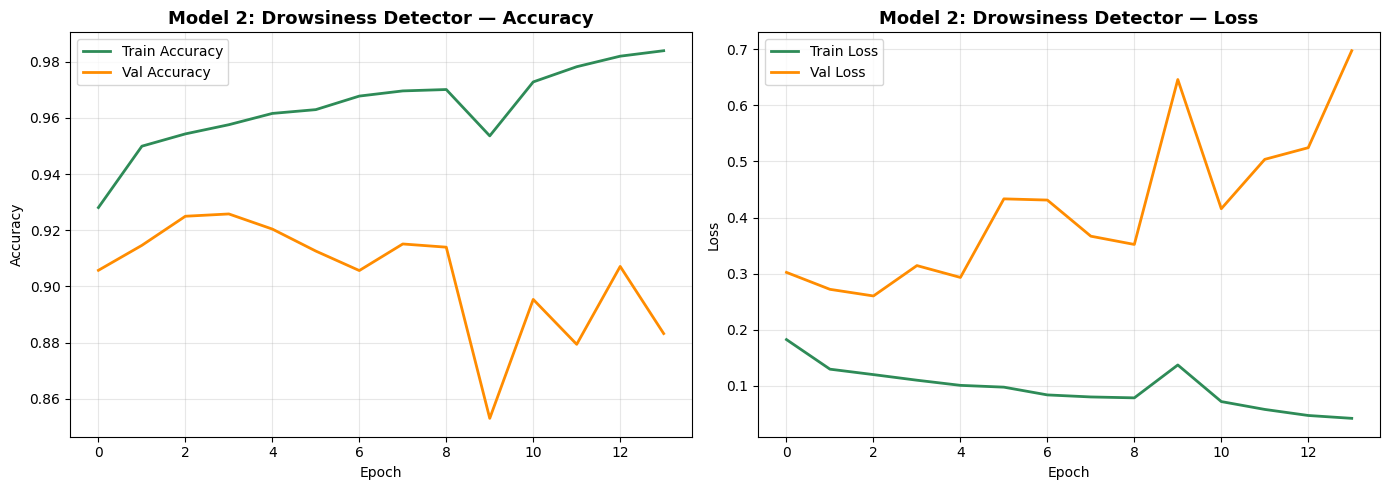

drowsiness_training_curves.png saved.


In [20]:
# Training curves.
# Same restart-safety fallback as Cell 9 — load from pickled history files
# if the in-memory variables aren't available.
import pickle

try:
    eh1_dict = history_eye_p1.history
    eh2_dict = history_eye_p2.history
except NameError:
    print("history_eye_p1/p2 not in memory — loading from pickled files instead.")
    with open('/kaggle/working/history_eye_p1.pkl', 'rb') as f:
        eh1_dict = pickle.load(f)
    with open('/kaggle/working/history_eye_p2.pkl', 'rb') as f:
        eh2_dict = pickle.load(f)

eye_history = combine_histories(eh1_dict, eh2_dict)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(eye_history['accuracy'], label='Train Accuracy', color='seagreen', linewidth=2)
axes[0].plot(eye_history['val_accuracy'], label='Val Accuracy', color='darkorange', linewidth=2)
axes[0].set_title('Model 2: Drowsiness Detector — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eye_history['loss'], label='Train Loss', color='seagreen', linewidth=2)
axes[1].plot(eye_history['val_loss'], label='Val Loss', color='darkorange', linewidth=2)
axes[1].set_title('Model 2: Drowsiness Detector — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/drowsiness_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("drowsiness_training_curves.png saved.")


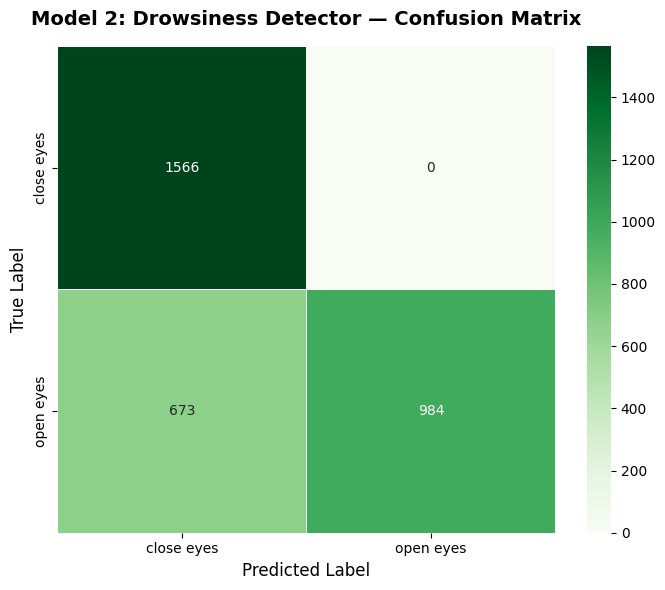

drowsiness_confusion_matrix.png saved.


In [21]:
# Confusion matrix
cm_eye = confusion_matrix(y_true_eye, y_pred_eye)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_eye,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=eye_labels,
    yticklabels=eye_labels,
    linewidths=0.5
)
plt.title('Model 2: Drowsiness Detector — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/drowsiness_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("drowsiness_confusion_matrix.png saved.")

---
## Cell 15 — Final Summary

In [33]:
print("=" * 55)
print("   DRIVER SAFETY MONITORING — RESULTS SUMMARY")
print("=" * 55)

# Final evaluation
emotion_model = load_model('/kaggle/working/emotion_model_best.h5')

test_gen.reset()
_, acc_emotion = emotion_model.evaluate(test_gen, verbose=0)

eye_test_gen.reset()
_, acc_eye = drowsiness_model.evaluate(eye_test_gen, verbose=0)

print("Model 1 — Emotion Classifier (FER-2013)")
print(f"  Dataset     : 35,887 images, 7 emotion classes")
print(f"  Architecture: MobileNetV2 + Transfer Learning")
print(f"  Test Accuracy: {acc_emotion*100:.2f}%")

print("Model 2 — Drowsiness Detector (MRL Eye)")
print(f"  Dataset     : ~84,000 images, Binary (Open/Closed)")
print(f"  Architecture: MobileNetV2 + Transfer Learning")
print(f"  Test Accuracy: {acc_eye*100:.2f}%")

print("Output files:")
output_files = [
    'emotion_model_best.h5',
    'drowsiness_model_best.h5',
    'emotion_training_curves.png',
    'emotion_confusion_matrix.png',
    'drowsiness_training_curves.png',
    'drowsiness_confusion_matrix.png'
]
for f in output_files:
    path = f'/kaggle/working/{f}'
    exists = os.path.exists(path)
    size = os.path.getsize(path) / (1024*1024) if exists else 0
    status = f"{size:.1f} MB" if exists else "NOT FOUND"
    print(f"  {'✓' if exists else '✗'} {f} — {status}")

print("=" * 55)

   DRIVER SAFETY MONITORING — RESULTS SUMMARY


Model 1 — Emotion Classifier (FER-2013)
  Dataset     : 35,887 images, 7 emotion classes
  Architecture: MobileNetV2 + Transfer Learning
  Test Accuracy: 53.08%
Model 2 — Drowsiness Detector (MRL Eye)
  Dataset     : ~84,000 images, Binary (Open/Closed)
  Architecture: MobileNetV2 + Transfer Learning
  Test Accuracy: 79.12%
Output files:
  ✓ emotion_model_best.h5 — 23.7 MB
  ✓ drowsiness_model_best.h5 — 9.8 MB
  ✓ emotion_training_curves.png — 0.1 MB
  ✓ emotion_confusion_matrix.png — 0.1 MB
  ✓ drowsiness_training_curves.png — 0.1 MB
  ✓ drowsiness_confusion_matrix.png — 0.0 MB


---
# Real-Time Inference Script

Local inference script. Requires: `tensorflow`, `opencv-python`, `mediapipe`.

Run: `python demo.py`

In [23]:
# demo.py — Run locally on laptop after downloading model files
#
# Requires: tensorflow, opencv-python, mediapipe
# Also requires emotion_class_indices.json and eye_class_indices.json
# (saved automatically in Cells 4 and 11) so label order always matches
# what the models were actually trained on.
#
# Run: python demo.py

demo_script = """
import json
import cv2
import numpy as np
import mediapipe as mp
from tensorflow.keras.models import load_model

# Load trained models
emotion_model = load_model('emotion_model_best.h5')
drowsiness_model = load_model('drowsiness_model_best.h5')

# Load label order exactly as produced during training, instead of
# hardcoding/assuming alphabetical order.
with open('emotion_class_indices.json') as f:
    _emotion_indices = json.load(f)
EMOTION_LABELS = [None] * len(_emotion_indices)
for name, idx in _emotion_indices.items():
    EMOTION_LABELS[idx] = name

with open('eye_class_indices.json') as f:
    _eye_indices = json.load(f)
EYE_LABELS = [None] * len(_eye_indices)
for name, idx in _eye_indices.items():
    EYE_LABELS[idx] = name

HIGH_RISK_EMOTIONS = ['Angry', 'Fear', 'Sad']

# Face detector (bounding box) + Face Mesh (landmarks, for accurate eye crop)
mp_face = mp.solutions.face_detection
mp_mesh = mp.solutions.face_mesh
face_detector = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.6)
face_mesh = mp_mesh.FaceMesh(max_num_faces=1, refine_landmarks=True,
                              min_detection_confidence=0.6, min_tracking_confidence=0.6)

# MediaPipe Face Mesh landmark indices around each eye
LEFT_EYE_IDX = [33, 133, 159, 145, 160, 144, 163, 7]
RIGHT_EYE_IDX = [362, 263, 386, 374, 387, 373, 390, 249]


def preprocess_face(frame, bbox, size=96):
    x, y, w, h = bbox
    face = frame[max(0, y):y + h, max(0, x):x + w]
    if face.size == 0:
        return None
    face = cv2.resize(face, (size, size))
    face = face.astype('float32') / 255.0
    return np.expand_dims(face, axis=0)


def get_eye_crop(frame, landmarks, idx_list, w_frame, h_frame, pad=8, size=96):
    xs = [int(landmarks[i].x * w_frame) for i in idx_list]
    ys = [int(landmarks[i].y * h_frame) for i in idx_list]
    x1, x2 = max(0, min(xs) - pad), min(w_frame, max(xs) + pad)
    y1, y2 = max(0, min(ys) - pad), min(h_frame, max(ys) + pad)
    if x2 <= x1 or y2 <= y1:
        return None
    eye = frame[y1:y2, x1:x2]
    if eye.size == 0:
        return None
    eye = cv2.resize(eye, (size, size))
    eye = eye.astype('float32') / 255.0
    return np.expand_dims(eye, axis=0)


# Webcam initialisation
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print('Inference running. Press Q to exit.')

frame_count = 0
current_emotion = 'Detecting...'
current_eye_state = 'Detecting...'

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    display = frame.copy()
    h_frame, w_frame = frame.shape[:2]

    # Inference every 3 frames to keep the loop responsive
    if frame_count % 3 == 0:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        det_results = face_detector.process(rgb)

        if det_results.detections:
            detection = det_results.detections[0]
            bbox_norm = detection.location_data.relative_bounding_box

            x = max(0, int(bbox_norm.xmin * w_frame))
            y = max(0, int(bbox_norm.ymin * h_frame))
            w = int(bbox_norm.width * w_frame)
            h = int(bbox_norm.height * h_frame)

            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)

            # Emotion prediction on the full face crop
            face_input = preprocess_face(frame, (x, y, w, h))
            if face_input is not None:
                probs = emotion_model.predict(face_input, verbose=0)[0]
                current_emotion = EMOTION_LABELS[int(np.argmax(probs))]

            # Eye-state prediction using landmark-based crops (both eyes)
            mesh_results = face_mesh.process(rgb)
            if mesh_results.multi_face_landmarks:
                landmarks = mesh_results.multi_face_landmarks[0].landmark
                left_input = get_eye_crop(frame, landmarks, LEFT_EYE_IDX, w_frame, h_frame)
                right_input = get_eye_crop(frame, landmarks, RIGHT_EYE_IDX, w_frame, h_frame)

                eye_preds = []
                for eye_input in (left_input, right_input):
                    if eye_input is not None:
                        p = drowsiness_model.predict(eye_input, verbose=0)[0][0]
                        eye_preds.append(p)

                if eye_preds:
                    avg_pred = float(np.mean(eye_preds))
                    current_eye_state = EYE_LABELS[int(avg_pred > 0.5)]

    # Overlay results
    risk_flag = current_emotion in HIGH_RISK_EMOTIONS or current_eye_state.lower().startswith('close')
    color = (0, 0, 255) if risk_flag else (0, 200, 0)

    cv2.putText(display, f'Emotion: {current_emotion}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.putText(display, f'Eyes: {current_eye_state}', (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    if risk_flag:
        cv2.putText(display, 'RISK DETECTED', (10, 90),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    cv2.imshow('Driver Safety Monitor', display)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
"""

# Write the script to disk so it's included in the output package
with open('/kaggle/working/demo.py', 'w') as f:
    f.write(demo_script)

print('demo.py written to /kaggle/working/demo.py')
print(f'Script length: {len(demo_script)} characters')


demo.py written to /kaggle/working/demo.py
Script length: 5121 characters


## Cell 16 — Package All Outputs as ZIP

In [34]:
import zipfile
import os

# Output files
output_files = [
    '/kaggle/working/emotion_model_best.h5',
    '/kaggle/working/drowsiness_model_best.h5',
    '/kaggle/working/emotion_training_curves.png',
    '/kaggle/working/emotion_confusion_matrix.png',
    '/kaggle/working/drowsiness_training_curves.png',
    '/kaggle/working/drowsiness_confusion_matrix.png',
    '/kaggle/working/emotion_class_indices.json',
    '/kaggle/working/eye_class_indices.json',
    '/kaggle/working/demo.py'
]

zip_path = '/kaggle/working/driver_safety_all_outputs.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for filepath in output_files:
        if os.path.exists(filepath):
            filename = os.path.basename(filepath)
            zf.write(filepath, filename)
            print(f'Added: {filename} ({os.path.getsize(filepath)/1024/1024:.2f} MB)')
        else:
            print(f'MISSING: {filepath}')

zip_size = os.path.getsize(zip_path) / 1024 / 1024
print(f'\nZIP created: driver_safety_all_outputs.zip ({zip_size:.2f} MB)')
print('ZIP saved: /kaggle/working/driver_safety_all_outputs.zip')


Added: emotion_model_best.h5 (23.67 MB)
Added: drowsiness_model_best.h5 (9.79 MB)
Added: emotion_training_curves.png (0.11 MB)
Added: emotion_confusion_matrix.png (0.10 MB)
Added: drowsiness_training_curves.png (0.10 MB)
Added: drowsiness_confusion_matrix.png (0.05 MB)
Added: emotion_class_indices.json (0.00 MB)
Added: eye_class_indices.json (0.00 MB)
Added: demo.py (0.00 MB)

ZIP created: driver_safety_all_outputs.zip (30.18 MB)
ZIP saved: /kaggle/working/driver_safety_all_outputs.zip


In [25]:
print(drowsiness_model.evaluate(eye_test_gen, verbose=0))

[0.7416874170303345, 0.7911883592605591]


In [26]:
# Unfreeze last 20 layers for fine-tuning
for layer in drowsiness_model.layers[:-20]:
    layer.trainable = False
for layer in drowsiness_model.layers[-20:]:
    layer.trainable = True

drowsiness_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 — fine-tuning last 20 layers")
print("-" * 40)

history_eye_p2 = drowsiness_model.fit(
    eye_train_gen,
    epochs=10,
    validation_data=eye_val_gen,
    callbacks=callbacks_eye,
    verbose=1
)

print("Model 2 training complete.")

Phase 2 — fine-tuning last 20 layers
----------------------------------------
Epoch 1/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9422 - loss: 0.2085
Epoch 1: val_accuracy did not improve from 0.92580
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 346s 307ms/step - accuracy: 0.9585 - loss: 0.1224 - val_accuracy: 0.8708 - val_loss: 0.7488 - learning_rate: 1.0000e-04
Epoch 2/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9725 - loss: 0.0725
Epoch 2: val_accuracy did not improve from 0.92580
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 250s 231ms/step - accuracy: 0.9740 - loss: 0.0702 - val_accuracy: 0.8329 - val_loss: 1.4145 - learning_rate: 1.0000e-04
Epoch 3/10
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9764 - loss: 0.0627
Epoch 3: val_accuracy did not improve from 0.92580

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1085/1085 ━━━━━━━━━━━━━━━━━━━━ 250s 231ms/step - accuracy: 0.9772 - loss: 0.0609 - val_accuracy: 0.8535 - val_loss: 0.73

In [27]:
eye_test_gen.reset()
loss_eye, acc_eye = drowsiness_model.evaluate(eye_test_gen, verbose=0)
print(f"Test Accuracy: {acc_eye*100:.2f}%")

Test Accuracy: 81.73%


In [29]:
# Save the current in-memory model (post fine-tuning, best weights restored)
drowsiness_model.save('/kaggle/working/drowsiness_model_best.h5')

# Test set evaluation
eye_test_gen.reset()
loss_eye, acc_eye = drowsiness_model.evaluate(eye_test_gen, verbose=0)
print(f"Test Accuracy: {acc_eye*100:.2f}%")
print(f"Test Loss: {loss_eye:.4f}")

# Predictions
eye_test_gen.reset()
y_pred_eye_probs = drowsiness_model.predict(eye_test_gen, verbose=1)
y_pred_eye = (y_pred_eye_probs > 0.5).astype(int).flatten()
y_true_eye = eye_test_gen.classes

eye_labels = list(eye_test_gen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true_eye, y_pred_eye, target_names=eye_labels))

Test Accuracy: 79.12%
Test Loss: 0.7417
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step
Classification Report:
              precision    recall  f1-score   support

  close eyes       0.70      1.00      0.82      1566
   open eyes       1.00      0.59      0.75      1657

    accuracy                           0.79      3223
   macro avg       0.85      0.80      0.78      3223
weighted avg       0.85      0.79      0.78      3223



In [30]:
eye_test_gen.reset()
print(drowsiness_model.evaluate(eye_test_gen, verbose=0))

[0.7416874170303345, 0.7911883592605591]


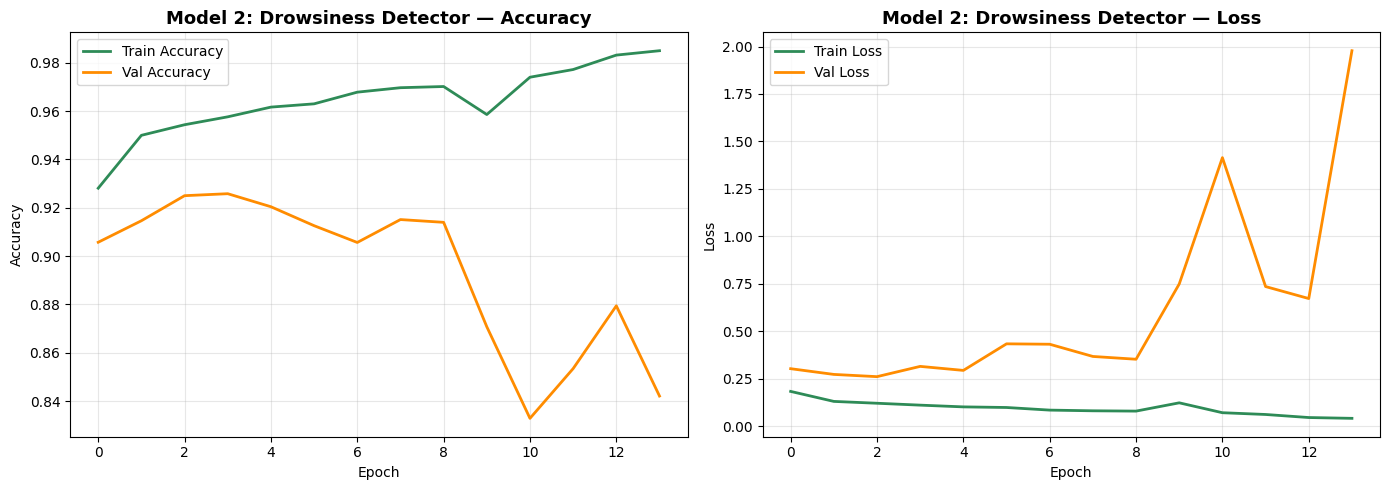

drowsiness_training_curves.png saved.


In [31]:
eye_history = combine_histories(history_eye_p1.history, history_eye_p2.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(eye_history['accuracy'], label='Train Accuracy', color='seagreen', linewidth=2)
axes[0].plot(eye_history['val_accuracy'], label='Val Accuracy', color='darkorange', linewidth=2)
axes[0].set_title('Model 2: Drowsiness Detector — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eye_history['loss'], label='Train Loss', color='seagreen', linewidth=2)
axes[1].plot(eye_history['val_loss'], label='Val Loss', color='darkorange', linewidth=2)
axes[1].set_title('Model 2: Drowsiness Detector — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/drowsiness_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("drowsiness_training_curves.png saved.")

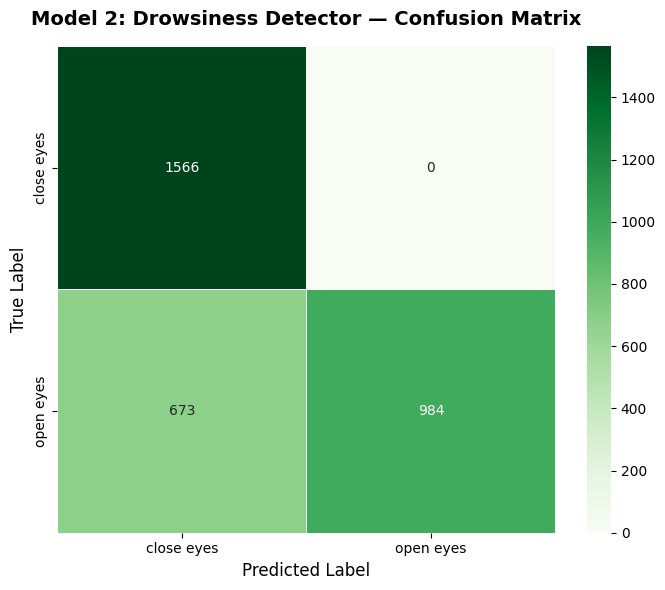

drowsiness_confusion_matrix.png saved.


In [32]:
cm_eye = confusion_matrix(y_true_eye, y_pred_eye)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_eye,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=eye_labels,
    yticklabels=eye_labels,
    linewidths=0.5
)
plt.title('Model 2: Drowsiness Detector — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/drowsiness_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("drowsiness_confusion_matrix.png saved.")

---
## Output Files to Download

| File | Description |
|---|---|
| `driver_safety_all_outputs.zip` | All outputs packaged |
| `emotion_model_best.h5` | Emotion classifier |
| `drowsiness_model_best.h5` | Drowsiness detector |
| `emotion_training_curves.png` | Training curves — Model 1 |
| `emotion_confusion_matrix.png` | Confusion matrix — Model 1 |
| `drowsiness_training_curves.png` | Training curves — Model 2 |
| `drowsiness_confusion_matrix.png` | Confusion matrix — Model 2 |
| `emotion_class_indices.json` | Emotion label order (used by `demo.py`) |
| `eye_class_indices.json` | Eye-state label order (used by `demo.py`) |
| `demo.py` | Real-time inference script (needs the two JSON files above alongside it) |
